<a href="https://colab.research.google.com/github/KarthikSaravanakumarM56/24ADI006-24BAD056-DL/blob/main/DL_Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EXPT NO: 7
# GENERATE SYNTHETIC IMAGES USING GAN
PART A: DATASET PREPARATION AND IMAGE PREPROCESSING


TensorFlow Version: 2.20.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)

Image height: 28
Image width: 28


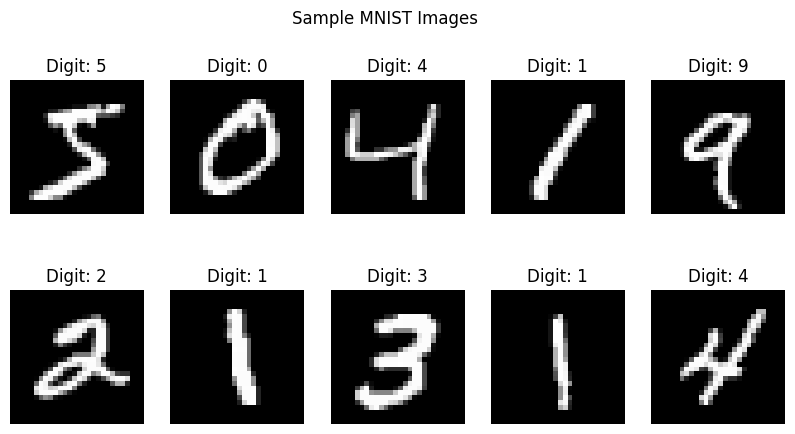


Minimum pixel value: -1.0
Maximum pixel value: 1.0
Reshaped training data: (60000, 28, 28, 1)

Dataset preparation completed.
Batch size: 256


In [1]:
# Roll No: 24BAD056
# Name: M. Karthik Saravanakumar

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("TensorFlow Version:", tf.__version__)

# 1. LOAD MNIST DATASET
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

# 2. CHECK IMAGE DIMENSIONS
print("\nImage height:", x_train.shape[1])
print("Image width:", x_train.shape[2])

# 3. DISPLAY SAMPLE IMAGES
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title("Digit: " + str(y_train[i]))
    plt.axis("off")
plt.suptitle("Sample MNIST Images")
plt.show()

# 4. NORMALIZE PIXEL VALUES TO [-1, 1]
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

print("\nMinimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

# 5. RESHAPE IMAGES
x_train = np.expand_dims(x_train, axis=-1)
print("Reshaped training data:", x_train.shape)

# 6. CREATE TF.DATA DATASET
BUFFER_SIZE = 60000
BATCH_SIZE = 256

train_dataset = tf.data.Dataset.from_tensor_slices(x_train)
train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

print("\nDataset preparation completed.")
print("Batch size:", BATCH_SIZE)

PART B: IMPLEMENTING THE GENERATOR

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       627,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        32,768 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 1)      │         1,569 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 818,081 (3.12 MB)

 Trainable params: 805,345 (3.07 MB)

 Non-trainable params: 12,736 (49.75 KB)

Generated image shape: (1, 28, 28, 1)


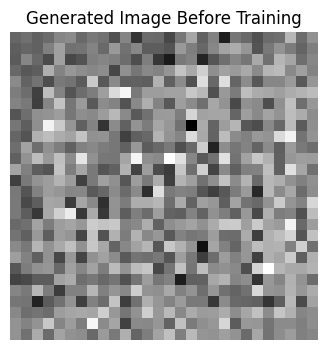

In [2]:
# Roll No: 24BAD056
# Name: M. Karthik Saravanakumar

# PART B: GENERATOR
LATENT_DIM = 100
def build_generator():
    model = tf.keras.Sequential(name="Generator")

    # Input: random noise vector
    model.add(
        tf.keras.layers.Dense(
            7 * 7 * 128,
            use_bias=False,
            input_shape=(LATENT_DIM,)
        )
    )
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.ReLU())

    # Convert vector into 7x7x128 feature map
    model.add(tf.keras.layers.Reshape((7, 7, 128)))

    # 7x7 -> 14x14
    model.add(
        tf.keras.layers.Conv2DTranspose(
            64,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False
        )
    )
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.ReLU())

    # 14x14 -> 28x28
    model.add(
        tf.keras.layers.Conv2DTranspose(
            32,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False
        )
    )
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.ReLU())

    # Final image
    model.add(
        tf.keras.layers.Conv2D(
            1,
            kernel_size=7,
            padding="same",
            activation="tanh"
        )
    )
    return model
generator = build_generator()

# DISPLAY GENERATOR SUMMARY
generator.summary()

# GENERATE IMAGE BEFORE TRAINING
noise = tf.random.normal([1, LATENT_DIM])
generated_image = generator(noise, training=False)
print("Generated image shape:", generated_image.shape)

# DISPLAY GENERATED IMAGE
plt.figure(figsize=(4, 4))
plt.imshow(
    generated_image[0, :, :, 0],
    cmap="gray"
)
plt.title("Generated Image Before Training")
plt.axis("off")
plt.show()

PART C: IMPLEMENTING THE DISCRIMINATOR AND GAN MODEL

In [3]:
# Roll No: 24BAD056
# Name: M. Karthik Saravanakumar

# PART C: DISCRIMINATOR
def build_discriminator():
    model = tf.keras.Sequential(name="Discriminator")
    model.add(
        tf.keras.layers.Conv2D(
            64,
            kernel_size=5,
            strides=2,
            padding="same",
            input_shape=(28, 28, 1)
        )
    )
    model.add(tf.keras.layers.LeakyReLU(alpha=0.2))
    model.add(tf.keras.layers.Dropout(0.3))
    model.add(
        tf.keras.layers.Conv2D(
            128,
            kernel_size=5,
            strides=2,
            padding="same"
        )
    )
    model.add(tf.keras.layers.LeakyReLU(alpha=0.2))
    model.add(tf.keras.layers.Dropout(0.3))
    model.add(tf.keras.layers.Flatten())
    model.add(
        tf.keras.layers.Dense(1)
    )
    return model
discriminator = build_discriminator()

# DISPLAY DISCRIMINATOR SUMMARY
discriminator.summary()

# TEST DISCRIMINATOR
decision = discriminator(generated_image)
print("Discriminator output shape:", decision.shape)
print("Discriminator output:", decision.numpy())

# LOSS FUNCTION
cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

# OPTIMIZERS
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)
discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)
print("\nDiscriminator and Generator are ready.")
print("Loss: Binary Cross-Entropy")
print("Optimizer: Adam")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

Discriminator output shape: (1, 1)
Discriminator output: [[0.00222649]]

Discriminator and Generator are ready.
Loss: Binary Cross-Entropy
Optimizer: Adam


PART D: GAN TRAINING AND SYNTHETIC IMAGE GENERATION

Starting GAN training...

Epoch 1/20 - Generator Loss: 0.7676 - Discriminator Loss: 1.2155


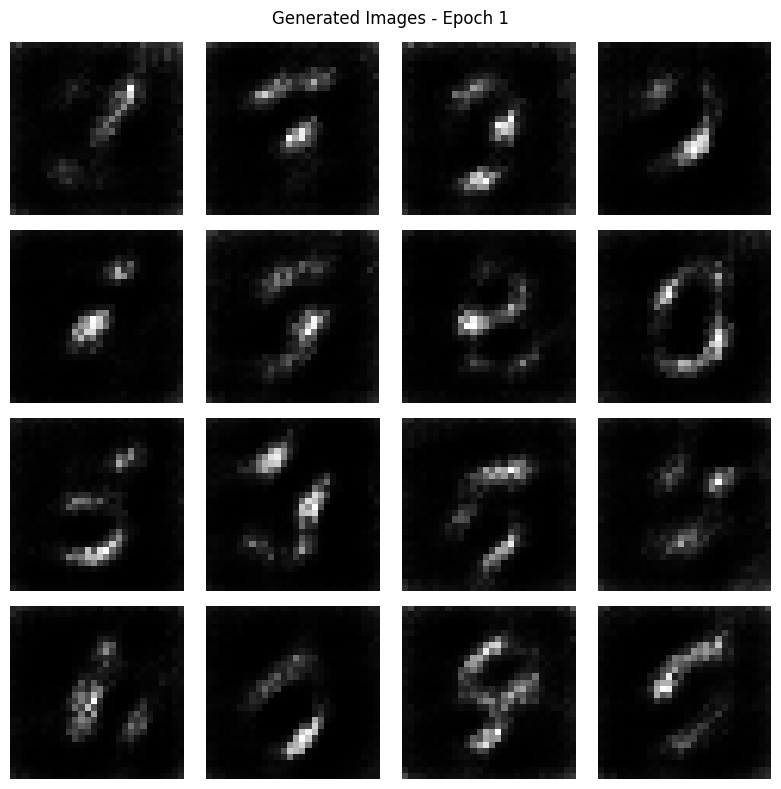

Epoch 2/20 - Generator Loss: 0.7456 - Discriminator Loss: 1.3324
Epoch 3/20 - Generator Loss: 0.7721 - Discriminator Loss: 1.3029
Epoch 4/20 - Generator Loss: 0.8088 - Discriminator Loss: 1.2667
Epoch 5/20 - Generator Loss: 0.7976 - Discriminator Loss: 1.2881


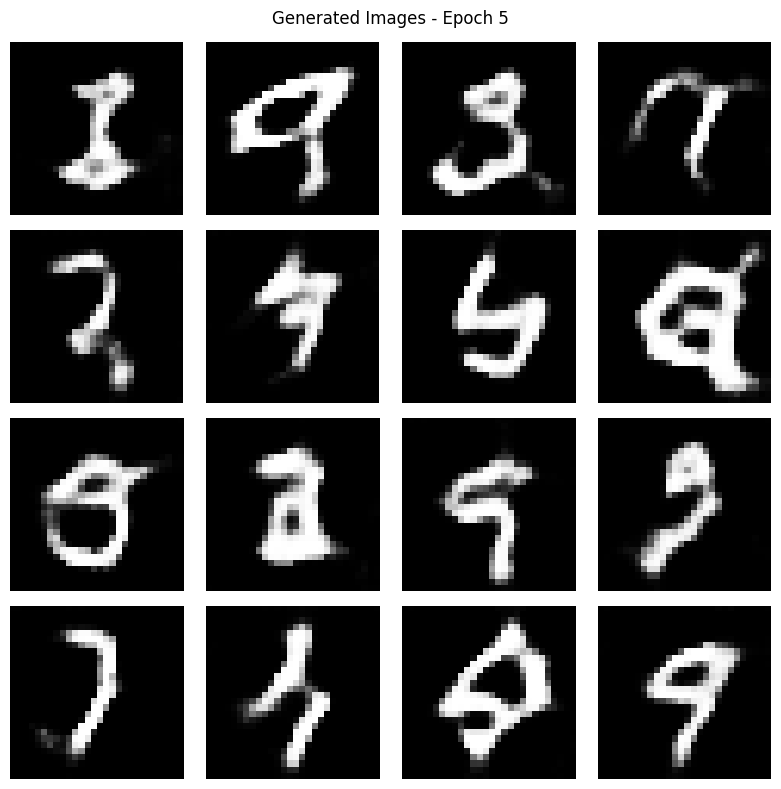

Epoch 6/20 - Generator Loss: 0.7869 - Discriminator Loss: 1.3051
Epoch 7/20 - Generator Loss: 0.7804 - Discriminator Loss: 1.3076
Epoch 8/20 - Generator Loss: 0.7740 - Discriminator Loss: 1.3132
Epoch 9/20 - Generator Loss: 0.7759 - Discriminator Loss: 1.3132
Epoch 10/20 - Generator Loss: 0.7759 - Discriminator Loss: 1.3127


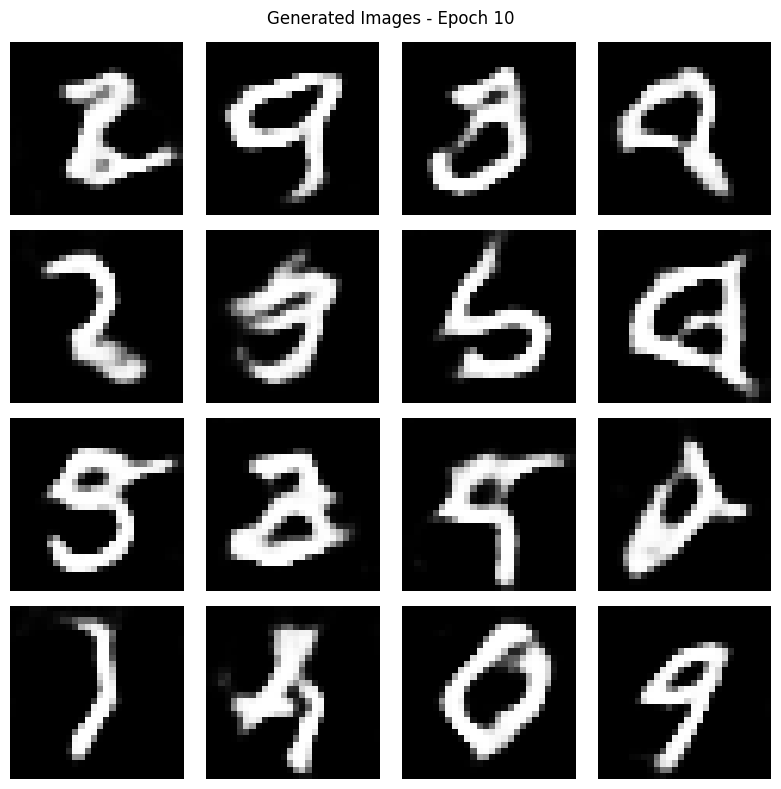

Epoch 11/20 - Generator Loss: 0.7799 - Discriminator Loss: 1.3111
Epoch 12/20 - Generator Loss: 0.7757 - Discriminator Loss: 1.3165
Epoch 13/20 - Generator Loss: 0.7742 - Discriminator Loss: 1.3158
Epoch 14/20 - Generator Loss: 0.7765 - Discriminator Loss: 1.3166
Epoch 15/20 - Generator Loss: 0.7749 - Discriminator Loss: 1.3183


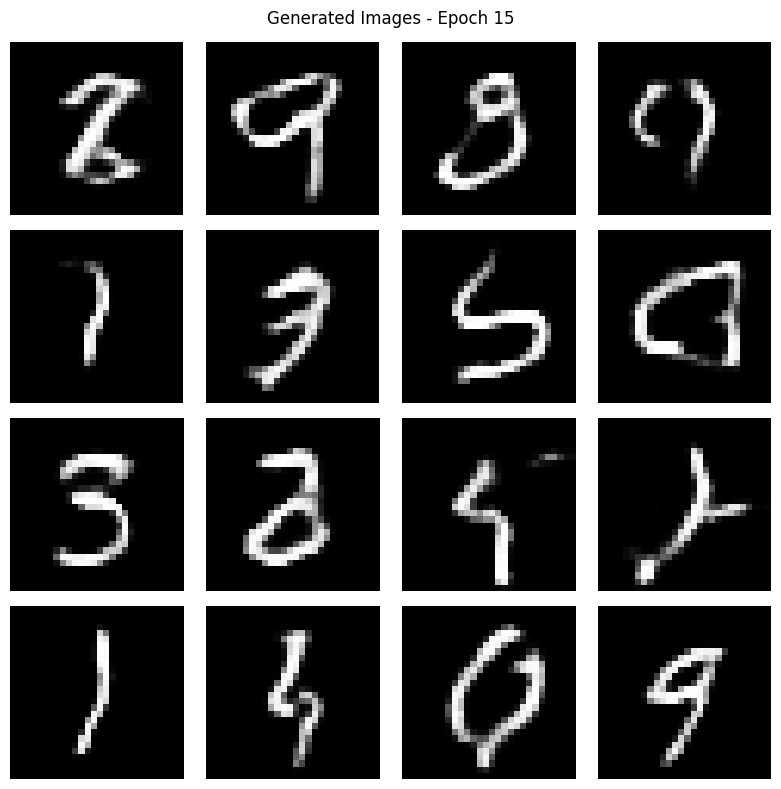

Epoch 16/20 - Generator Loss: 0.7752 - Discriminator Loss: 1.3170
Epoch 17/20 - Generator Loss: 0.7756 - Discriminator Loss: 1.3181
Epoch 18/20 - Generator Loss: 0.7803 - Discriminator Loss: 1.3155
Epoch 19/20 - Generator Loss: 0.7730 - Discriminator Loss: 1.3198
Epoch 20/20 - Generator Loss: 0.7736 - Discriminator Loss: 1.3206


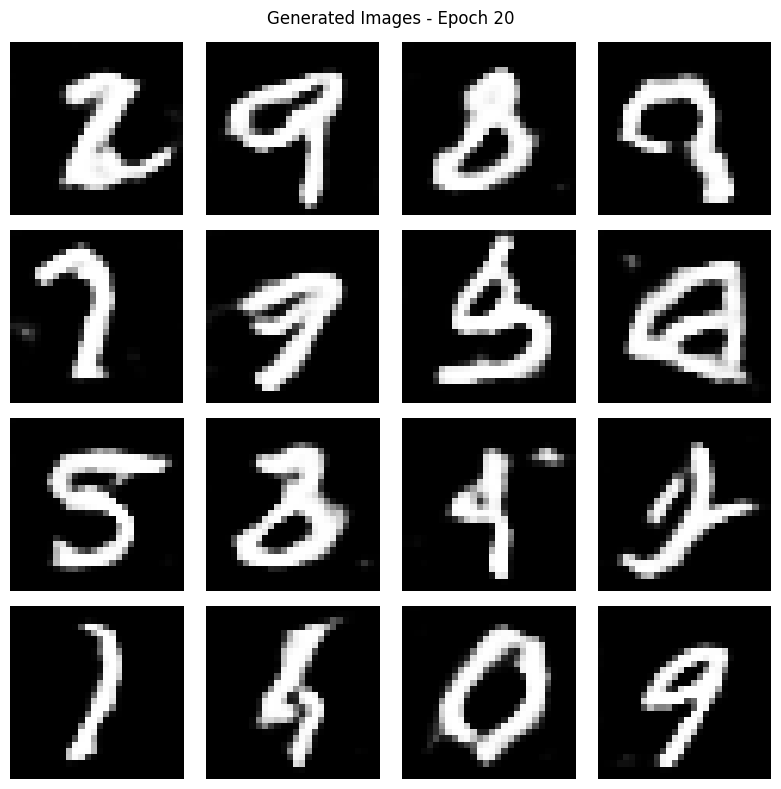

In [4]:
# Roll No: 24BAD056
# Name: M. Karthik Saravanakumar

# PART D: GAN TRAINING

EPOCHS = 20
NUM_EXAMPLES_TO_GENERATE = 16

# Fixed seed for observing improvement
seed = tf.random.normal(
    [NUM_EXAMPLES_TO_GENERATE, LATENT_DIM]
)

# Lists to store losses
generator_losses = []
discriminator_losses = []

# GENERATOR LOSS
def generator_loss(fake_output):
    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

# DISCRIMINATOR LOSS
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )
    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )
    total_loss = real_loss + fake_loss
    return total_loss

# TRAINING STEP
@tf.function
def train_step(images):

    # Generate random noise
    noise = tf.random.normal(
        [BATCH_SIZE, LATENT_DIM]
    )
    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        # Generate fake images
        generated_images = generator(
            noise,
            training=True
        )

        # Discriminator predictions
        real_output = discriminator(
            images,
            training=True
        )
        fake_output = discriminator(
            generated_images,
            training=True
        )

        # Calculate losses
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    # Calculate gradients
    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )
    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # Update weights
    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )
    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )
    return gen_loss, disc_loss

# FUNCTION TO GENERATE SAMPLE IMAGES
def generate_and_display_images(epoch):
    predictions = generator(
        seed,
        training=False
    )
    plt.figure(figsize=(8, 8))
    for i in range(
        NUM_EXAMPLES_TO_GENERATE
    ):
        plt.subplot(4, 4, i + 1)
        plt.imshow(
            predictions[i, :, :, 0],
            cmap="gray"
        )
        plt.axis("off")
    plt.suptitle(
        "Generated Images - Epoch " + str(epoch)
    )
    plt.tight_layout()
    plt.show()

# TRAIN GAN
print("Starting GAN training...\n")

for epoch in range(1, EPOCHS + 1):
    epoch_gen_loss = []
    epoch_disc_loss = []

    for image_batch in train_dataset:
        gen_loss, disc_loss = train_step(
            image_batch
        )
        epoch_gen_loss.append(
            float(gen_loss)
        )
        epoch_disc_loss.append(
            float(disc_loss)
        )

    # Average losses
    avg_gen_loss = np.mean(epoch_gen_loss)
    avg_disc_loss = np.mean(epoch_disc_loss)
    generator_losses.append(
        avg_gen_loss
    )
    discriminator_losses.append(
        avg_disc_loss
    )
    print(
        f"Epoch {epoch}/{EPOCHS} "
        f"- Generator Loss: {avg_gen_loss:.4f} "
        f"- Discriminator Loss: {avg_disc_loss:.4f}"
    )

    # Display images at regular intervals
    if epoch == 1 or epoch % 5 == 0:
        generate_and_display_images(epoch)

PART D: FINAL OUTPUT, COMPARISON, ANALYSIS AND SAVING

1. GENERATOR AND DISCRIMINATOR LOSS


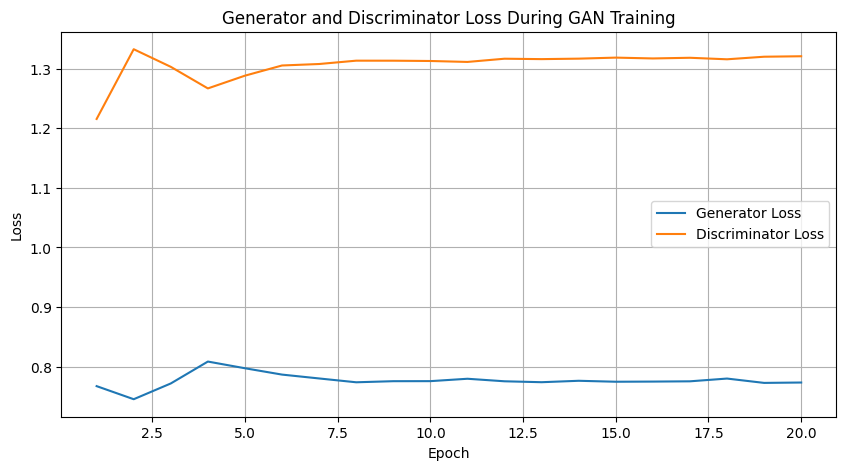

2. FINAL SYNTHETIC IMAGE GENERATION
Final synthetic images generated successfully.
Number of images: 25
Image shape: (25, 28, 28, 1)


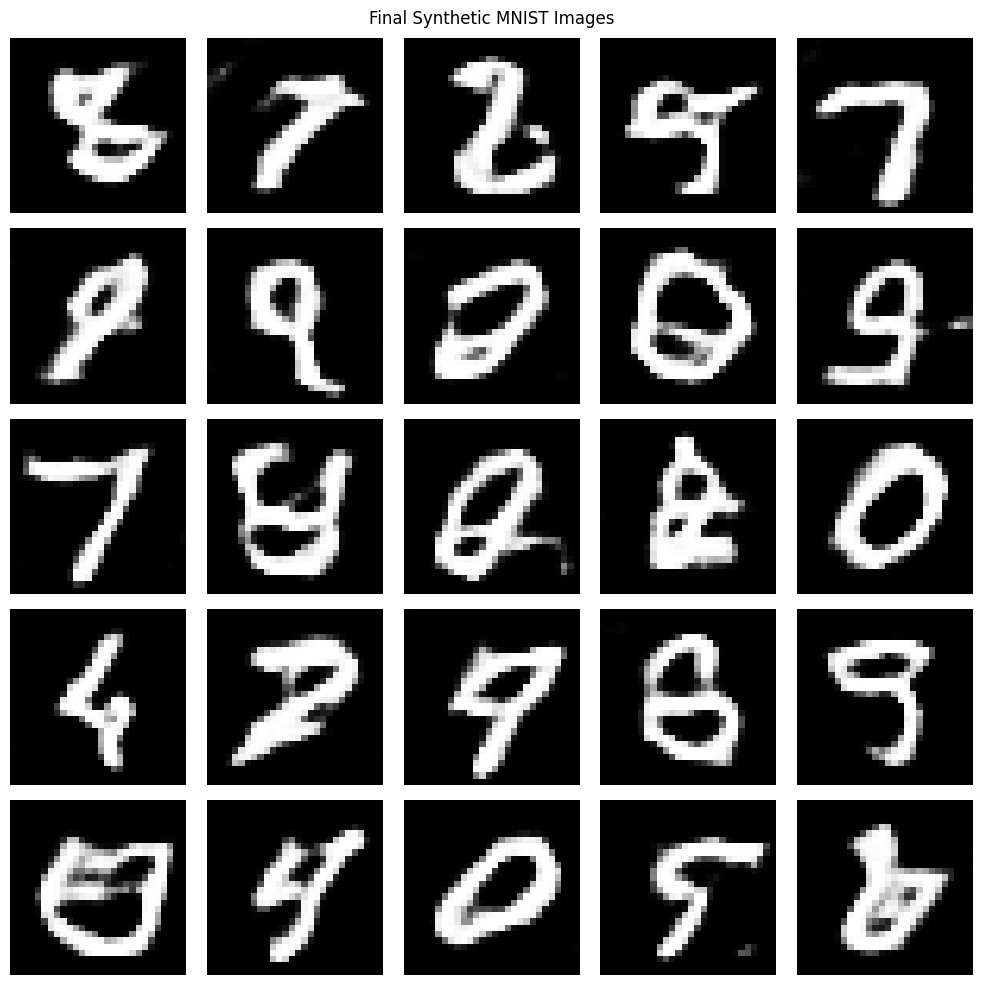

3. REAL VS SYNTHETIC IMAGE COMPARISON


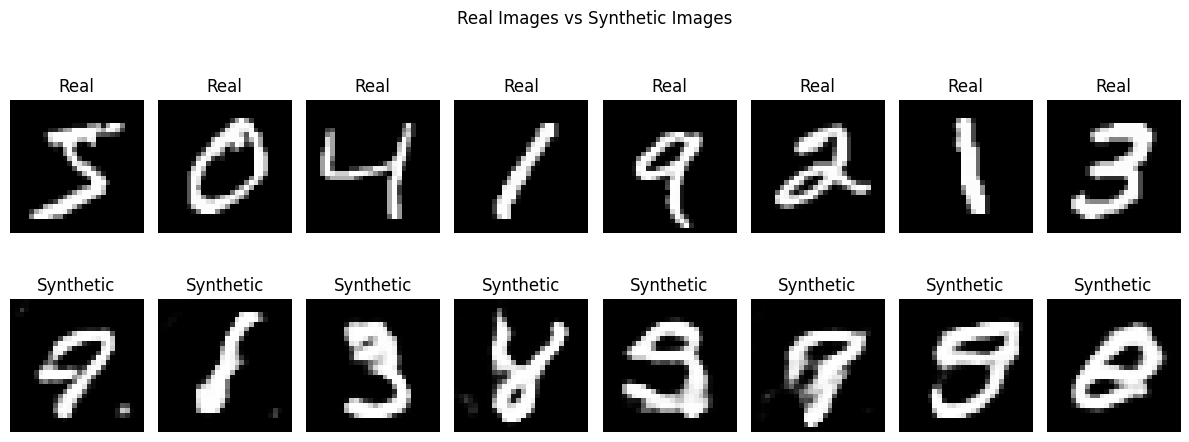

4. QUALITY AND DIVERSITY ANALYSIS


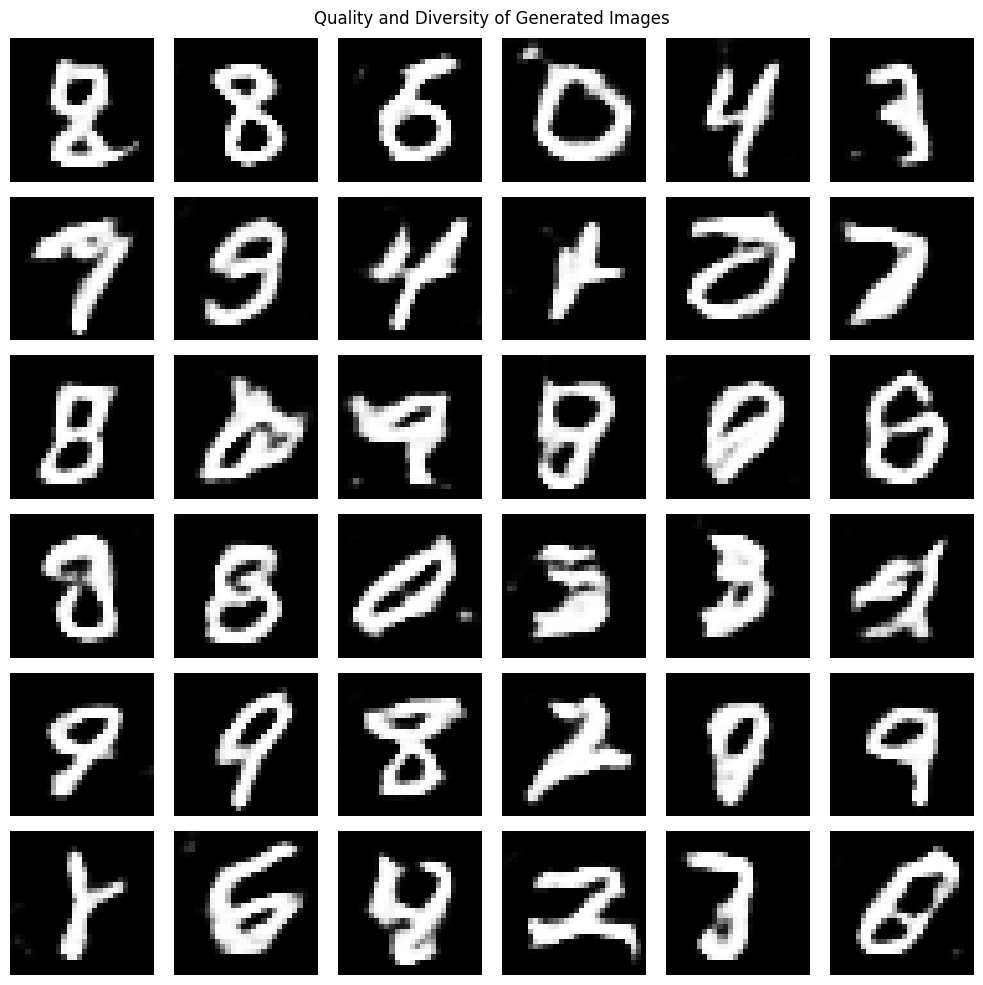

Quality and diversity analysis completed.
5. SAVING FINAL GENERATED IMAGES
25 synthetic images saved successfully.
Saved folder: generated_images
6. SAVING TRAINED GENERATOR
Trained Generator saved successfully.


PART D COMPLETED SUCCESSFULLY
✓ GAN training completed
✓ Generator loss recorded
✓ Discriminator loss recorded
✓ Final synthetic images generated
✓ Real and synthetic images compared
✓ Image quality and diversity visualized
✓ Generated images saved
✓ Trained Generator saved


In [5]:
# Roll No: 24BAD056
# Name: M. Karthik Saravanakumar

# 1. PLOT GENERATOR AND DISCRIMINATOR LOSS
print("=" * 60)
print("1. GENERATOR AND DISCRIMINATOR LOSS")
print("=" * 60)

plt.figure(figsize=(10, 5))
plt.plot(
    range(1, EPOCHS + 1),
    generator_losses,
    label="Generator Loss"
)
plt.plot(
    range(1, EPOCHS + 1),
    discriminator_losses,
    label="Discriminator Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Generator and Discriminator Loss During GAN Training")
plt.legend()
plt.grid(True)
plt.show()

# 2. GENERATE FINAL SYNTHETIC IMAGES
print("=" * 60)
print("2. FINAL SYNTHETIC IMAGE GENERATION")
print("=" * 60)

FINAL_IMAGES = 25

# Generate random noise
final_noise = tf.random.normal(
    [FINAL_IMAGES, LATENT_DIM]
)

# Generate synthetic images
final_images = generator(
    final_noise,
    training=False
)
print("Final synthetic images generated successfully.")
print("Number of images:", FINAL_IMAGES)
print("Image shape:", final_images.shape)

# Display final generated images
plt.figure(figsize=(10, 10))
for i in range(FINAL_IMAGES):
    plt.subplot(5, 5, i + 1)
    plt.imshow(
        final_images[i, :, :, 0],
        cmap="gray"
    )
    plt.axis("off")
plt.suptitle(
    "Final Synthetic MNIST Images"
)
plt.tight_layout()
plt.show()

# 3. REAL VS SYNTHETIC IMAGE COMPARISON
print("=" * 60)
print("3. REAL VS SYNTHETIC IMAGE COMPARISON")
print("=" * 60)
COMPARE_COUNT = 8

# Generate synthetic images
comparison_noise = tf.random.normal(
    [COMPARE_COUNT, LATENT_DIM]
)
synthetic_images = generator(
    comparison_noise,
    training=False
)
plt.figure(figsize=(12, 5))

# REAL IMAGES
for i in range(COMPARE_COUNT):
    plt.subplot(2, 8, i + 1)

    # Convert [-1, 1] to [0, 1]
    real_image = (
        x_train[i, :, :, 0] + 1
    ) / 2
    plt.imshow(
        real_image,
        cmap="gray"
    )
    plt.title("Real")
    plt.axis("off")

# SYNTHETIC IMAGES
for i in range(COMPARE_COUNT):
    plt.subplot(2, 8, i + 9)

    # Convert [-1, 1] to [0, 1]
    fake_image = (
        synthetic_images[i, :, :, 0] + 1
    ) / 2
    plt.imshow(
        fake_image,
        cmap="gray"
    )
    plt.title("Synthetic")
    plt.axis("off")
plt.suptitle(
    "Real Images vs Synthetic Images"
)
plt.tight_layout()
plt.show()

# 4. QUALITY AND DIVERSITY ANALYSIS
print("=" * 60)
print("4. QUALITY AND DIVERSITY ANALYSIS")
print("=" * 60)

QUALITY_COUNT = 36

# Generate random noise
quality_noise = tf.random.normal(
    [QUALITY_COUNT, LATENT_DIM]
)

# Generate synthetic images
quality_images = generator(
    quality_noise,
    training=False
)

# Display generated images
plt.figure(figsize=(10, 10))
for i in range(QUALITY_COUNT):
    plt.subplot(6, 6, i + 1)
    plt.imshow(
        quality_images[i, :, :, 0],
        cmap="gray"
    )
    plt.axis("off")
plt.suptitle(
    "Quality and Diversity of Generated Images"
)
plt.tight_layout()
plt.show()
print("Quality and diversity analysis completed.")

# 5. SAVE FINAL GENERATED IMAGES
print("=" * 60)
print("5. SAVING FINAL GENERATED IMAGES")
print("=" * 60)

import os
SAVE_FOLDER = "generated_images"

# Create folder
os.makedirs(
    SAVE_FOLDER,
    exist_ok=True
)

# Save each generated image
for i in range(FINAL_IMAGES):

    # Get image
    image = final_images[
        i, :, :, 0
    ].numpy()

    # Convert [-1, 1] to [0, 1]
    image = (image + 1) / 2

    # Save image
    file_path = os.path.join(
        SAVE_FOLDER,
        f"synthetic_{i + 1}.png"
    )
    plt.imsave(
        file_path,
        image,
        cmap="gray"
    )
print(
    FINAL_IMAGES,
    "synthetic images saved successfully."
)
print(
    "Saved folder:",
    SAVE_FOLDER
)

# 6. SAVE TRAINED GENERATOR
print("=" * 60)
print("6. SAVING TRAINED GENERATOR")
print("=" * 60)

generator.save(
    "trained_GAN_generator.keras"
)
print(
    "Trained Generator saved successfully."
)

# FINAL MESSAGE
print("\n")
print("=" * 60)
print("PART D COMPLETED SUCCESSFULLY")
print("=" * 60)

print("✓ GAN training completed")
print("✓ Generator loss recorded")
print("✓ Discriminator loss recorded")
print("✓ Final synthetic images generated")
print("✓ Real and synthetic images compared")
print("✓ Image quality and diversity visualized")
print("✓ Generated images saved")
print("✓ Trained Generator saved")
print("=" * 60)